# Sentence Reconstruction

The purpose of this project is to take in input a sequence of words corresponding to a random permutation of a given english sentence, and reconstruct the original sentence.

The otuput can be either produced in a single shot, or through an iterative (autoregressive) loop generating a single token at a time.


CONSTRAINTS:
* No pretrained model can be used.
* The neural network models should have less the 20M parameters.
* No postprocessing should be done (e.g. no beamsearch)
* You cannot use additional training data.


BONUS PARAMETERS:

A bonus of 0-2 points will be attributed to incentivate the adoption of models with a low number of parameters.

# Dataset

The dataset is composed by sentences taken from the generics_kb dataset of hugging face. We restricted the vocabolary to the 10K most frequent words, and only took sentences making use of this vocabulary.

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

In [ ]:
!pip install datasets

Download the dataset

In [ ]:
from datasets import load_dataset
from keras.layers import TextVectorization
import tensorflow as tf
import numpy as np

np.random.seed(42)
ds = load_dataset('generics_kb',trust_remote_code=True)['train']

Filter row with length greater than 8.


In [2]:
ds = ds.filter(lambda row: len(row["generic_sentence"].split(" ")) > 8 )
corpus = [ '<start> ' + row['generic_sentence'].replace(","," <comma>") + ' <end>' for row in ds ]
corpus = np.array(corpus)

Filter:   0%|          | 0/1020868 [00:00<?, ? examples/s]

Create a tokenizer and Detokenizer

In [3]:
tokenizer=TextVectorization( max_tokens=10000, standardize="lower_and_strip_punctuation", encoding="utf-8",) #con il max prende le piu frequenti. ordina i token del vocab dal piu frequente al meno frequente
tokenizer.adapt(corpus)

class TextDetokenizer:
    def __init__(self, vectorize_layer):
        self.vectorize_layer = vectorize_layer
        vocab = self.vectorize_layer.get_vocabulary()
        self.index_to_word = {index: word for index, word in enumerate(vocab)}

    def __detokenize_tokens(self, tokens):
        def check_token(t):
          if t == 3:
            s="<start>"
          elif t == 2:
            s="<end>"
          elif t == 7:
            s="<comma>"
          else:
            s=self.index_to_word.get(t, '[UNK]')
          return s

        return ' '.join([ check_token(token) for token in tokens if token != 0])

    def __call__(self, batch_tokens):
       return [self.__detokenize_tokens(tokens) for tokens in batch_tokens]


detokenizer = TextDetokenizer( tokenizer )
sentences = tokenizer( corpus ).numpy()


Remove from corpus the sentences where any unknow word appears

In [5]:
mask = np.sum( (sentences==1) , axis=1) >= 1
original_data = np.delete( sentences, mask , axis=0)

In [82]:
original_data.shape

(241236, 28)

Shuffle the sentences

In [ ]:
seq_len=28

In [6]:
from tensorflow.keras.utils import Sequence
from tensorflow.keras.preprocessing.sequence import pad_sequences

class DataGenerator(Sequence):
    def __init__(self, data, training=True, batch_size=32, shuffle=True):

        self.data = data
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.training = training
        self.on_epoch_end()

    def __len__(self):
        return int(np.floor(len(self.data) / self.batch_size))

    def __getitem__(self, index):
        indexes = self.indexes[index*self.batch_size:(index+1)*self.batch_size]
        data_batch = np.array([self.data[k] for k in indexes])
        result = np.copy(data_batch)

        #shuffle only the relevant positions for each batch
        for i in range(data_batch.shape[0]):
            np.random.shuffle(data_batch[i,1:data_batch[i].argmin() - 1])
    
    # =============== MY CODE ================== #
        # teacher forcing
        targ_in = result[:, :-1]
        targ_out = result[:, 1:]
        # test_data = data_batch[:, :-1]
        
        # Pad sequences
        data_batch = pad_sequences(data_batch, maxlen=seq_len, padding='post')
        targ_in = pad_sequences(targ_in, maxlen=seq_len, padding='post')
        targ_out = pad_sequences(targ_out, maxlen=seq_len, padding='post')
        # test_data = pad_sequences(test_data, maxlen=seq_len, padding='post')

        # Generate padding masks (2D)
        encoder_padding_mask = data_batch != 0
        decoder_padding_mask = targ_in != 0

        # Reshape to 3D masks
        encoder_padding_mask = tf.expand_dims(encoder_padding_mask, axis=2)
        encoder_padding_mask = tf.repeat(encoder_padding_mask, repeats=seq_len, axis=2)

        decoder_padding_mask = tf.expand_dims(decoder_padding_mask, axis=2)
        decoder_padding_mask = tf.repeat(decoder_padding_mask, repeats=seq_len, axis=2)

        
        # Generate look-ahead masks (lower triangular matrix)
        look_ahead_mask = 1 - tf.linalg.band_part(tf.ones((self.batch_size, seq_len, seq_len)), -1, 0)
        look_ahead_mask = tf.cast(look_ahead_mask, dtype=tf.int32)

        if(self.training):
            return (data_batch, encoder_padding_mask, targ_in, decoder_padding_mask, look_ahead_mask), targ_out
        else:
            return (data_batch, encoder_padding_mask, _, decoder_padding_mask, look_ahead_mask), targ_out

    def on_epoch_end(self):
        self.indexes = np.arange(len(self.data))
        if self.shuffle:
            np.random.shuffle(self.indexes)

In [ ]:
# train_generator = DataGenerator(original_data[:220000])
# test_generator = DataGenerator(original_data[220000:])
# x, y = test_generator.__getitem__(1)
# x = detokenizer(x[0])
# y = detokenizer(y)

# for i in range(7):
#   print("original: ", y[i])
#   print("shuffled: ", x[i])
#   print("\n")

# Metrics

Let s be the source string and p your prediction. The quality of the results will be measured according to the following metric:

1.  look for the longest substring w between s and p
2.  compute |w|/max(|s|,|p|)

If the match is exact, the score is 1.

When computing the score, you should NOT consider the start and end tokens.



The longest common substring can be computed with the SequenceMatcher function of difflib, that allows a simple definition of our metric.

In [7]:
from difflib import SequenceMatcher

def score(s,p):
    match = SequenceMatcher(None, s, p).find_longest_match()
    return (match.size/max(len(p),len(s)))

Let's do an example.

In [ ]:
original = "at first henry wanted to be friends with the king of france"
generated = "henry wanted to be friends with king of france at the first"
print("your score is ",score(original,generated))

The score must be computed as an average of at least 3K random examples taken form the test set.

# What to deliver

You are supposed to deliver a single notebook, suitably commented.
The notebook should describe a single model, although you may briefly discuss additional attempts you did.

The notebook should contain a full trace of the training.
Weights should be made available on request.

You must also give a clear assesment of the performance of the model, computed with the metric that has been given to you.

# Good work!

In [92]:
from keras.layers import LayerNormalization, MultiHeadAttention, Add, Input, Dense, Embedding, Layer, Dropout
from keras.models import Model
from keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

Positional encoding inject positional information into the input embeddings of the model. The positional encoding values are calculated using sine and cosine functions, which create a pattern that allows the model to differentiate between tokens based on their position in the sequence.

In [9]:
### Positional Encoding ###
def positional_encoding(max_sequence_len, model_dim):
    """
    :param max_sequence_len: the maximum length of the sequence
    :param model_dim: the embedding dimension
    """
    
    # Positions of the words and embedding dimensions
    positions = np.arange(max_sequence_len)[:, np.newaxis]
    dimensions = np.arange(model_dim)[np.newaxis, :]

    angle_rates = 1 / np.power(10000, (2 * (dimensions // 2)) / np.float32(model_dim))
    angle_rads = positions * angle_rates

    # apply sin to even indices in the array; 2i
    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])

    # apply cos to odd indices in the array; 2i+1
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

    pos_encoding = angle_rads[np.newaxis, ...]
    return pos_encoding

In [32]:
class CombineMasks(Layer):
    def call(self, inputs):
        padding_mask, look_ahead_mask = inputs
        combined_mask = tf.logical_or(padding_mask, look_ahead_mask)
        return combined_mask

In [59]:
### Transformer Block ###
def transformer_block(latent_dim, num_heads, feed_forward_dim, dropout_rate):
    """
    :param latent_dim: the embedding dimension
    :param num_heads: the number of heads in the multiheadattention models
    :param feed_forward_dim: the number of neurons in the feedforward network
    :param dropout_rate: the dropout rate
    """

    input_layer = Input(shape=(None, latent_dim))
    
    # Multi-head attention
    attention = MultiHeadAttention(num_heads=num_heads, key_dim=latent_dim // num_heads, dropout=dropout_rate)
    attention_output = attention(input_layer, input_layer, input_layer, use_causal_mask=True)
    attention_output = Dropout(dropout_rate)(attention_output)
    attention_output = Add()([input_layer, attention_output])
    attention_output = LayerNormalization()(attention_output)
    
    # Feedforward
    outputs = Dense(feed_forward_dim, activation='relu')(attention_output)
    outputs = Dense(latent_dim)(outputs)
    outputs = Dropout(dropout_rate)(outputs)
    outputs = Add()([attention_output, outputs])
    outputs = LayerNormalization()(outputs)

    return Model(input_layer, outputs)

In [60]:
### Encoder Block ###
def encoder_block(latent_dim, num_heads, feed_forward_dim, dropout_rate):
    input_layer = Input(shape=(None, latent_dim))
    mask = Input(shape=(None, None), dtype='bool')  # padding mask

    # Multi-head attention
    attention = MultiHeadAttention(num_heads=num_heads, key_dim=latent_dim // num_heads, dropout=dropout_rate)
    attention_output = attention(input_layer, input_layer, input_layer,  use_causal_mask=True, attention_mask=mask)
    attention_output = Dropout(dropout_rate)(attention_output)
    attention_output = Add()([input_layer, attention_output])
    attention_output = LayerNormalization()(attention_output)

    # Feedforward
    outputs = Dense(feed_forward_dim, activation='relu')(attention_output)
    outputs = Dense(latent_dim)(outputs)
    outputs = Dropout(dropout_rate)(outputs)
    outputs = Add()([attention_output, outputs])
    outputs = LayerNormalization()(outputs)

    return Model([input_layer, mask], outputs) 

In [61]:
### Decoder Block ###
from tensorflow.keras.layers import Reshape
def decoder_block(latent_dim, num_heads, feed_forward_dim, dropout_rate):

    input_layer = Input(shape=(None, latent_dim)) # teacher forcing
    encoder_output = Input(shape=(None, latent_dim))
    
    # Masks
    padding_mask = Input(shape=(None, 28), dtype='bool')  
    look_ahead_mask = Input(shape=(None, 28), dtype='bool')
    combined_mask = CombineMasks()([padding_mask, look_ahead_mask])

    # Self-attention
    attention1 = MultiHeadAttention(num_heads=num_heads, key_dim=latent_dim // num_heads, dropout=dropout_rate)
    attention_output1 = attention1(input_layer, input_layer, input_layer, use_causal_mask=True, attention_mask=padding_mask)
    attention_output1 = Dropout(dropout_rate)(attention_output1)
    attention_output1 = Add()([input_layer, attention_output1])
    attention_output1 = LayerNormalization()(attention_output1)
     
    # Encoder-decoder attention
    attention2 = MultiHeadAttention(num_heads=num_heads, key_dim=latent_dim // num_heads, dropout=dropout_rate)
    attention_output2 = attention2(attention_output1, encoder_output, encoder_output, use_causal_mask=True,attention_mask=padding_mask)
    attention_output2 = Dropout(dropout_rate)(attention_output2)
    attention_output2 = Add()([attention_output1, attention_output2])
    attention_output2 = LayerNormalization()(attention_output2)

    # Feedforward
    outputs = Dense(feed_forward_dim, activation='relu')(attention_output2)
    outputs = Dense(latent_dim)(outputs)
    outputs = Dropout(dropout_rate)(outputs)
    outputs = Add()([attention_output2, outputs])
    outputs = LayerNormalization()(outputs)

    return Model([input_layer, encoder_output, padding_mask, look_ahead_mask], outputs)

In [112]:
### Transformer Model ###
def transformer_model(latent_dim, num_heads, feed_forward_dim, dropout_rate, max_sequence_len, num_transformer_blocks, vocab_size):
    """
    :param latent_dim: the embedding dimension
    :param num_heads: the number of heads in the multiheadattention models
    :param feed_forward_dim: the number of neurons in the feedforward network
    :param dropout_rate: the dropout rate
    :param max_sequence_len: the maximum sequence length
    :param num_transformer_blocks: the number of transformer blocks
    :param vocab_size: the size of the vocabulary
    """

    # Encoder
    encoder_inputs = Input(shape=(max_sequence_len,))
    encoder_mask = Input(shape=(None,max_sequence_len), dtype='bool')
    encoder_embedding = Embedding(vocab_size, latent_dim)(encoder_inputs)
    # pos_encoding = positional_encoding(max_sequence_len, latent_dim)
    # encoder_outputs = encoder_embedding + pos_encoding
    encoder_outputs = encoder_embedding

    for i in range(num_transformer_blocks):
        encoder_outputs = encoder_block(latent_dim, num_heads, feed_forward_dim, dropout_rate)([encoder_outputs, encoder_mask])

    # Decoder
    decoder_inputs = Input(shape=(max_sequence_len,))
    decoder_padding = Input(shape=(None,28), dtype='bool')
    look_ahead_mask = Input(shape=(None,28), dtype='bool')
    
    decoder_embedding = Embedding(vocab_size, latent_dim)(decoder_inputs)
    pos_encoding = positional_encoding(max_sequence_len, latent_dim)
    decoder_outputs = decoder_embedding + pos_encoding

    for i in range(num_transformer_blocks):
        decoder_outputs = decoder_block(latent_dim, num_heads, feed_forward_dim, dropout_rate)([decoder_outputs, encoder_outputs, decoder_padding, look_ahead_mask])

    # Attention
    # attention = MultiHeadAttention(num_heads=num_heads, key_dim=latent_dim // num_heads, dropout=dropout_rate)
    # context_vector = attention(decoder_outputs, encoder_outputs, encoder_outputs)
    # decoder_combined_context = Concatenate()([context_vector, decoder_outputs])

    # Re-adapt dimension
    decoder_outputs = Dense(latent_dim, activation='relu')(decoder_outputs)

    # Transformer block
    decoder_outputs = encoder_block(latent_dim, num_heads, feed_forward_dim, dropout_rate)([decoder_outputs, encoder_mask])

    # Output layer
    decoder_outputs = Dense(vocab_size, activation='softmax')(decoder_outputs)

    return Model([encoder_inputs, encoder_mask, decoder_inputs, decoder_padding, look_ahead_mask], decoder_outputs)

### Loss function & Metric
The sparse categorical cross-entropy and accuracy are extended to include a padding mask.


In [63]:
def masked_loss(y_true, y_pred):
    mask = tf.math.logical_not(tf.math.equal(y_true, 0))
    loss_object = tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=False, reduction='none')
    
    loss_ = loss_object(y_true, y_pred)
    mask = tf.cast(mask, dtype=loss_.dtype)
    loss_ *= mask

    return tf.reduce_sum(loss_)/tf.reduce_sum(mask)

In [ ]:
def masked_accuracy(y_true, y_pred):
    mask = tf.math.logical_not(tf.math.equal(y_true, 0))
    correct = tf.cast(tf.math.equal(y_true, tf.argmax(y_pred, axis=-1, output_type=tf.int32)), dtype=tf.float32)
    mask = tf.cast(mask, dtype=correct.dtype)
    correct *= mask

    return tf.reduce_sum(correct)/tf.maximum(tf.reduce_sum(mask), 1)

### Compiling the Model

In [64]:
class CustomSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
  def __init__(self, d_model, warmup_steps=4000):
    super().__init__()

    self.d_model = d_model
    self.d_model = tf.cast(self.d_model, tf.float32)

    self.warmup_steps = warmup_steps

  def __call__(self, step):
    step = tf.cast(step, dtype=tf.float32)
    arg1 = tf.math.rsqrt(step)
    arg2 = step * (self.warmup_steps ** -1.5)

    return tf.math.rsqrt(self.d_model) * tf.math.minimum(arg1, arg2)

  def get_config(self):
    return {
        'd_model': self.d_model,
        'warmup_steps': self.warmup_steps
    } 

In [113]:
latent_dim = 256
num_heads = 16
feed_forward_dim = 512

dropout_rate = 0.2
max_sequence_len = 28
num_transformer_blocks = 4

vocab_size = len(tokenizer.get_vocabulary())
learning_rate = CustomSchedule(latent_dim)

optimizer = tf.keras.optimizers.Adam(learning_rate, beta_1=0.9, 
                                     beta_2=0.98, epsilon=1e-9)

model = transformer_model(latent_dim, num_heads, feed_forward_dim, dropout_rate, max_sequence_len, num_transformer_blocks, vocab_size)
# model.compile(optimizer=Adam(), loss='sparse_categorical_crossentropy')

model.compile(optimizer=optimizer, loss=masked_loss, metrics=[masked_accuracy])
model.summary()

Model: "functional_213"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_303     │ (None, 28)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_22        │ (None, 28, 256)   │  2,560,000 │ input_layer_303[… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_304     │ (None, None, 28)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_195      │ (None, 28, 256)   │    527,104 │ embedding_22[0][… │
│ (Functional)        │                   │            │ input_layer_304[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_313     │ (None, 28)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_197      │ (None, 28, 256)   │    527,104 │ functional_195[0… │
│ (Functional)        │                   │            │ input_layer_304[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_23        │ (None, 28, 256)   │  2,560,000 │ input_layer_313[… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_199      │ (None, 28, 256)   │    527,104 │ functional_197[0… │
│ (Functional)        │                   │            │ input_layer_304[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_232 (Add)       │ (None, 28, 256)   │          0 │ embedding_23[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_201      │ (None, 28, 256)   │    527,104 │ functional_199[0… │
│ (Functional)        │                   │            │ input_layer_304[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_314     │ (None, None, 28)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_315     │ (None, None, 28)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_203      │ (None, 28, 256)   │    790,784 │ add_232[0][0],    │
│ (Functional)        │                   │            │ functional_201[0… │
│                     │                   │            │ input_layer_314[… │
│                     │                   │            │ input_layer_315[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_205      │ (None, 28, 256)   │    790,784 │ functional_203[0… │
│ (Functional)        │                   │            │ functional_201[0… │
│                     │                   │            │ input_layer_314[… │
│                     │                   │            │ input_layer_315[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_207      │ (None, 28, 256)   │    790,784 │ functional_205[0… │
│ (Functional)        │                   │            │ functional_201[0… │
│                     │                   │            │ input_layer_314[… │
│                     │                   │            │ input_layer_315[

 Total params: 13,554,448 (51.71 MB)

 Trainable params: 13,554,448 (51.71 MB)

 Non-trainable params: 0 (0.00 B)

### Training the Model

In [114]:
train_generator = DataGenerator(original_data[:220000], training=True, batch_size=256)
test_generator = DataGenerator(original_data[230000:], training=False, batch_size=256)
val_generator = DataGenerator(original_data[220000:230000], training=False, batch_size=256)

In [ ]:
### FIRST TRAINING ###
from keras.callbacks import EarlyStopping
# checkpoint_path = "/content/drive/MyDrive/Colab/PRJ/transformer10_128_64_16_8_8.h5"
# checkpoint = ModelCheckpoint(checkpoint_path, save_best_only=True)
# early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)

early_stopping = EarlyStopping(monitor='val_masked_accuracy', mode='max', verbose=1, patience=5)
history1 = model.fit(train_generator, epochs=15, validation_data=val_generator, callbacks=[early_stopping])
# model.save('v2_3_128_256_16.keras')

Epoch 1/15


W0000 00:00:1718105474.940544     143 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


 17/859 ━━━━━━━━━━━━━━━━━━━━ 2:53 205ms/step - loss: 9.2588 - masked_accuracy: 1.1275e-04

In [108]:
### SECOND TRAINING ###
from tensorflow.keras.models import load_model

early_stopping = EarlyStopping(monitor='val_masked_accuracy', mode='max', verbose=1, patience=5)
history2 = model.fit(train_generator, epochs=15, validation_data=val_generator, callbacks=[early_stopping])
# model.save('v2_3_128_256_16.keras')

Epoch 1/15
859/859 ━━━━━━━━━━━━━━━━━━━━ 185s 215ms/step - loss: 2.7208 - masked_accuracy: 0.5218 - val_loss: 7.7706 - val_masked_accuracy: 0.0918
Epoch 2/15
859/859 ━━━━━━━━━━━━━━━━━━━━ 184s 214ms/step - loss: 2.6512 - masked_accuracy: 0.5306 - val_loss: 7.7169 - val_masked_accuracy: 0.0921
Epoch 3/15
859/859 ━━━━━━━━━━━━━━━━━━━━ 184s 215ms/step - loss: 2.5940 - masked_accuracy: 0.5379 - val_loss: 7.8246 - val_masked_accuracy: 0.0914
Epoch 4/15
859/859 ━━━━━━━━━━━━━━━━━━━━ 184s 214ms/step - loss: 2.5416 - masked_accuracy: 0.5452 - val_loss: 7.8652 - val_masked_accuracy: 0.0932
Epoch 5/15
859/859 ━━━━━━━━━━━━━━━━━━━━ 184s 214ms/step - loss: 2.5015 - masked_accuracy: 0.5499 - val_loss: 7.9163 - val_masked_accuracy: 0.0903
Epoch 6/15
859/859 ━━━━━━━━━━━━━━━━━━━━ 185s 215ms/step - loss: 2.4588 - masked_accuracy: 0.5554 - val_loss: 8.0292 - val_masked_accuracy: 0.0935
Epoch 7/15
859/859 ━━━━━━━━━━━━━━━━━━━━ 184s 214ms/step - loss: 2.4255 - masked_accuracy: 0.5601 - val_loss: 7.9286 - val_ma

### Testing

To make predictions, the model is used in autoregressive mode, namely it predicts one token at a time, and at each step the decoder's output becomes its input for the next step.

In [22]:
def clean_sentence(x):
    x = x.replace('<start>', '').replace('<end>', '').replace('<pad>', '').strip()
    return x

In [20]:
### Predict One Token at a Time ###
def predict(encoder_input, encoder_padding_mask, targ_in, decoder_padding_mask, look_ahead_mask, model, max_sequence_len=28):
    
    batch_size = encoder_input.shape[0]
    predictions = np.zeros((batch_size, max_sequence_len))
    
    # words of each sentence in the batch
    bow = [[word for word in sentence if word not in [3, 2, 0]] for sentence in encoder_input]

    # initialize predictions
    for i in range(batch_size):
        predictions[i,0] = 3 # <start> token

    for i in range(1, max_sequence_len):
        output = model.predict([encoder_input, encoder_padding_mask, 
                                predictions, decoder_padding_mask, look_ahead_mask])

        # i-th word predicted, for each sentence of the batch
        token = output[:, i-1, :]
 
        # for each sentence in the batch
        for j in range(len(bow)):
            
            # end token
            if len(bow[j]) == 0:
                cand_token = 2 
            else:
                # choose only words that appears in the sentence
                predicted_words = token[j, np.array(bow[j])]
                
                # choose the most likely word
                best_word_index = np.argmax(predicted_words)
                best_word = bow[j][best_word_index]
                del bow[j][best_word]
            
            # add the predicted word to the sentence
            predictions[j,i] = best_word
            
    return predictions

In [ ]:
### Show Predicted Sentences ###
x, y_true = test_generator.__getitem__(1)
data_batch = x[0] 
encoder_padding_mask = x[1] 
targ_in = x[2]
decoder_padding_mask = x[3]
look_ahead_mask = x[4]

y_pred = predict(data_batch, encoder_padding_mask, targ_in, decoder_padding_mask, look_ahead_mask, model)

for true, pred in zip(y_true, y_pred):
    s_pred = clean_sentence ( detokenizer([pred])[0] )
    s_true = clean_sentence ( detokenizer([true])[0] )
    
    print("Predicted: ", s_pred)
    print("True: ", s_true)
    print('\n')

Baseline is evaluated as random predictions. The function below just shuffle again the sentence to make predictions.

In [ ]:
import random
def evaluate_baseline(test_generator, score_func):
    scores = []

    for i in range(len(test_generator)):
        x, y_true = test_generator.__getitem__(i)
        shuffled = x[0].copy()
        random.shuffle(shuffled)

        for true, shuffle in zip(detokenizer(y_true), detokenizer(shuffled)):
            scores.append(score_func(true, shuffle))
    
    return np.mean(scores), np.std(scores)

In [ ]:
baseline_mean, baseline_std = evaluate_baseline(test_generator, score)
print (f'Baseline score: {baseline_mean}')
print (f'Baseline Stdev: {baseline_std}')
print (f'Baseline 3*Stdev: {baseline_std * 3}')

In [110]:
def evaluate_model(model, test_generator, score_func):
    scores = []

    for i in range(len(test_generator) // 25 ):
        
        print("Test :", i)
        x, y_true = test_generator.__getitem__(i)
        y_pred = predict(*x, model)
        
        for true, pred in zip(y_true, y_pred):
            s_pred = clean_sentence ( detokenizer([pred])[0] )
            s_true = clean_sentence ( detokenizer([true])[0] )
            scores.append(score_func(s_true, s_pred))

    return np.mean(scores), np.std(scores)

In [111]:
average_score, stdev_score = evaluate_model(model, test_generator, score)
print(f'Average score: {average_score}')
print(f'Stdev: {stdev_score}')
print(f'3*Stdev: {stdev_score * 3}')

Test : 0
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
8/8 ━

In [ ]:
# Improvement over random guess
improvement = (average_score - baseline_mean) / baseline_mean
print(f'Improvement over random guess: {improvement}')

total epochs:  5
total steps:  320
dict_keys(['loss', 'masked_accuracy', 'val_loss', 'val_masked_accuracy'])


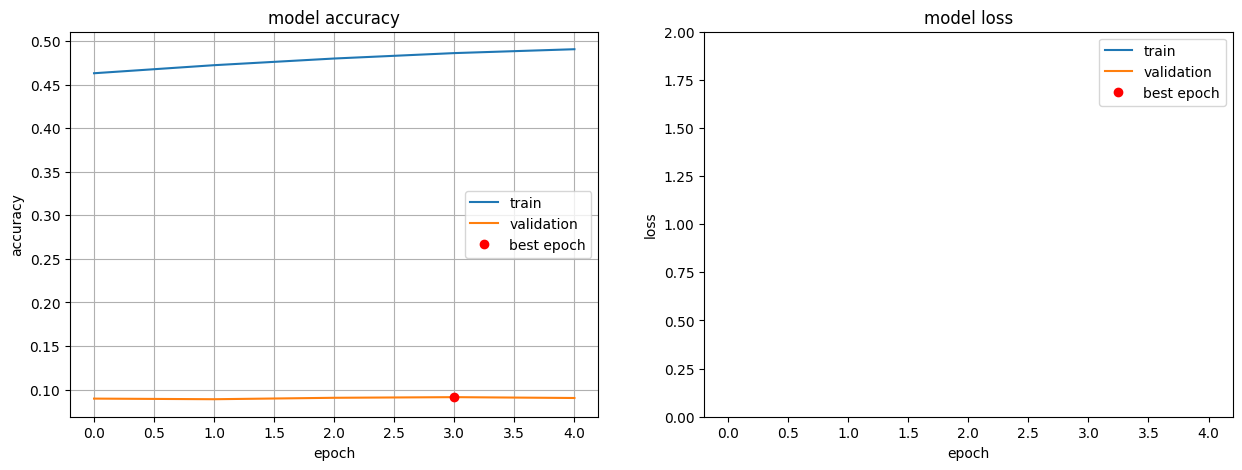

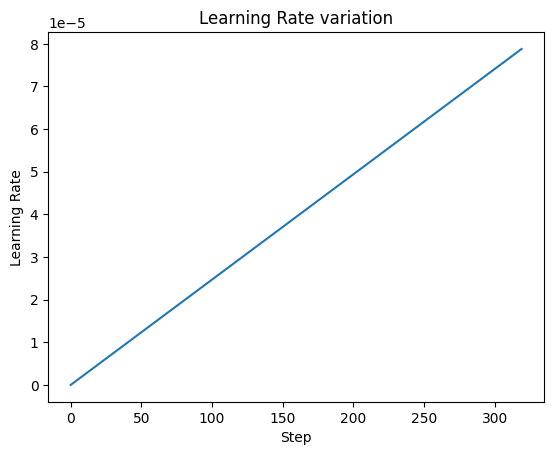

In [102]:
# for key in history1.history.keys():
#         history1.history[key].extend(history2.history[key])

history = history2
batch_size = 64

# Number of steps and epochs done
print("total epochs: ", len(history.history["loss"]))
print("total steps: ", len(history.history["loss"]) * batch_size)

# Accuracy Plots
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.grid()

print(history.history.keys())

plt.plot(history.history['masked_accuracy'], label="train")
plt.plot(history.history['val_masked_accuracy'], label="validation")

# Red point = best epoch for validation accuracy
best_epoch=np.argmax(history.history['val_masked_accuracy'])
plt.plot(best_epoch,history.history['val_masked_accuracy'][best_epoch],'ro', label="best epoch")
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend()

# Loss Plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label="train")
plt.plot(history.history['val_loss'], label="validation")

# Red point = best epoch for validation loss
best_epoch=np.argmin(history.history['val_loss'])
plt.plot(best_epoch,history.history['val_loss'][best_epoch],'ro', label="best epoch")
plt.title('model loss')
plt.ylabel('loss')
plt.ylim([0, 2])
plt.xlabel('epoch')
plt.legend()
plt.show()

# Learning Rate
learning_rates = [learning_rate(step).numpy() for step in range(len(history.history['loss'])*batch_size)]
plt.plot(np.arange(len(learning_rates)), learning_rates)
plt.title("Learning Rate variation")
plt.xlabel("Step")
plt.ylabel("Learning Rate")
plt.show()